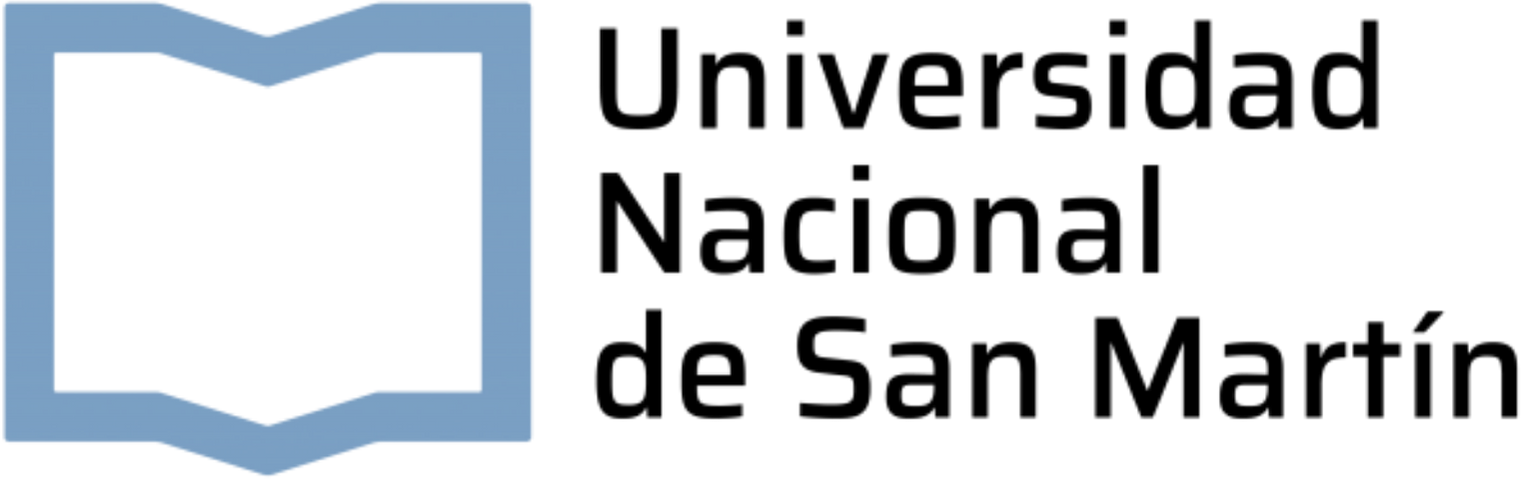

# TS5: Estimación espectral: Ancho de banda de señales reales
# Cristóbal Contador

## Introducción

En esta práctica se tiene como objetivo analizar y comparar la Densidad Espectral de Potencia (PSD) y el ancho de banda de distintas señales reales, incluyendo señales biomédicas (ECG, PPG y bioimpedancia torácica) y señales de audio. La idea es observar cómo se distribuye la potencia de cada señal en frecuencia y comparar las características espectrales de los distintos registros.

En este trabajo nos enfocamos en analizar el contenido frecuencial mediante los siguientes grupos de señales:

* **Señales de ECG:** se analizan dos registros, uno con ruido y otro sin ruido, con el objetivo de observar cómo la presencia de ruido modifica la distribución de potencia en frecuencia.

* **Señales de PPG:** se analizan dos registros, uno con ruido y otro sin ruido, para comparar sus características espectrales y observar las diferencias producidas por la presencia de ruido.

* **Señales de audio:** se analizan tres registros de audio correspondientes a voz, una melodía y un silbido, con el objetivo de observar y comparar su contenido frecuencial mediante la estimación de la PSD.

* **Señal de bioimpedancia torácica:** se analiza un registro de bioimpedancia correspondiente a la actividad respiratoria, con el objetivo de estudiar su distribución de potencia en frecuencia y comparar sus características espectrales con las demás señales biomédicas y de audio.

En total, se estudian **ocho registros**, correspondientes a dos señales de ECG, dos de PPG, tres de audio y una de bioimpedancia torácica.

Para realizar estas estimaciones se utiliza el **método de Welch**, que permite obtener una estimación de la PSD dividiendo la señal en distintos segmentos, aplicando una ventana a cada uno y promediando los periodogramas obtenidos. De esta manera se busca obtener una estimación más estable de la densidad espectral de potencia.

A lo largo de esta práctica se analizarán los resultados mediante estos tres puntos:

* **Estimación de la PSD:** representación de la densidad espectral de potencia de cada señal para observar cómo se distribuye su potencia en frecuencia y reconocer sus principales componentes frecuenciales.

* **Estimación del ancho de banda:** cálculo del ancho de banda correspondiente al 95% de la potencia acumulada para cada señal y presentación de los resultados en una tabla para facilitar su comparación.

* **Comparación entre señales:** comparación de las características espectrales de los registros de ECG, PPG, audio y bioimpedancia, incluyendo la diferencia entre las señales con y sin ruido en los casos correspondientes.


Primero haremos todos nuestros imports.

In [1]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio


Ahora cargaremos nuestra señal **ECG sin ruido** y la graficaremos.


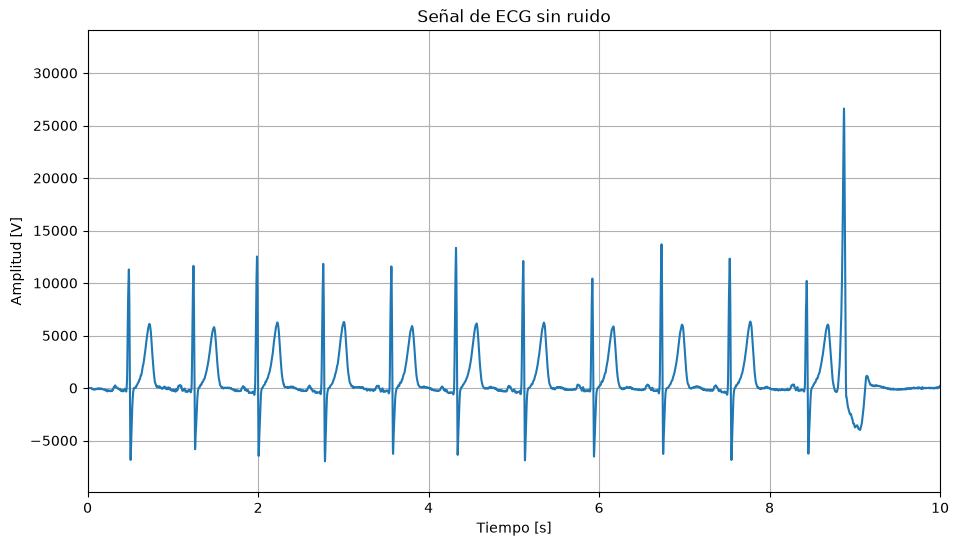

In [2]:
#%% ECG sin ruido

fs_ecgsinruido = 1000  # Hz

ecg_sinruido = np.load('ecg_sin_ruido.npy')

t_ecgsinruido = np.arange(len(ecg_sinruido)) / fs_ecgsinruido

plt.figure(figsize=(11, 6))
plt.plot(t_ecgsinruido, ecg_sinruido)

plt.title('Señal de ECG sin ruido')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim(0, 10)

plt.grid()
plt.show()

**Figura 1**. Señal de electrocardiograma (ECG) sin ruido, muestreada a una frecuencia de $f_s = 1000$ Hz. Se muestran los primeros 10 segundos del registro.


En la **Figura 1** podemos observar la señal de ECG sin ruido en función del tiempo, muestreada a una frecuencia de $f_s = 1000$ Hz. Para poder observar con mayor claridad la forma de la señal, se muestran los primeros 10 segundos del registro.

En la señal se pueden distinguir los distintos latidos cardíacos a lo largo del intervalo mostrado. En cada uno se observa la forma característica del ECG, donde se pueden identificar las ondas P, el complejo QRS y la onda T. Al no presentar ruido, estas características se pueden observar con mayor claridad.

También se puede observar que la señal mantiene una línea de base relativamente estable durante el registro, sin variaciones grandes que dificulten la identificación de los latidos.



Y ahora pasaremos a hacer la **estimación espectral** y la **estimación del ancho de banda**.


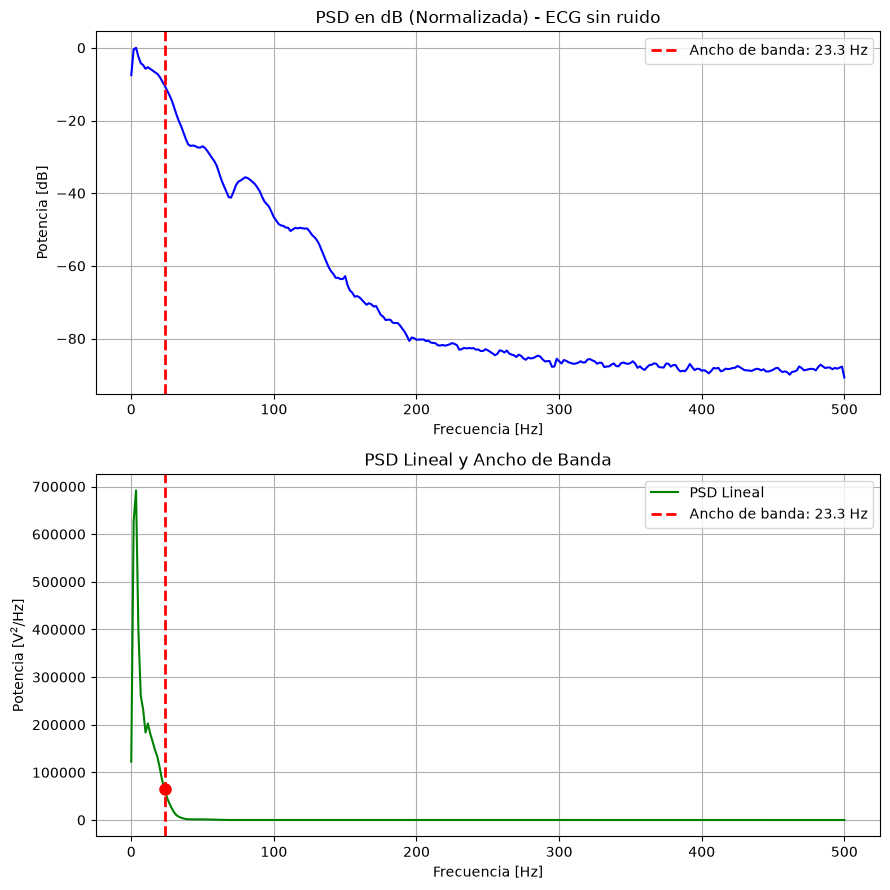

Ancho de banda: 23.33 Hz


In [3]:
N_ecgsinruido = len(ecg_sinruido) 
k_ecgsinruido = 50 
nperseg_ecgsinruido = N_ecgsinruido // k_ecgsinruido 

welch_ecgsinruido = sig.welch(ecg_sinruido, fs=fs_ecgsinruido, nperseg = nperseg_ecgsinruido) 

f_ecgsinruido, Pxx_ecgsinruido = welch_ecgsinruido 

Pxxdb_ecgsinruido = 10 * np.log10(np.abs(Pxx_ecgsinruido/np.max(Pxx_ecgsinruido)))

potacum_ecgsinruido = np.cumsum(Pxx_ecgsinruido) / np.sum(Pxx_ecgsinruido)

bw_ecgsinruido = f_ecgsinruido[potacum_ecgsinruido >= 0.95][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))


ax1.plot(f_ecgsinruido, Pxxdb_ecgsinruido, color='b')
ax1.axvline(bw_ecgsinruido, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bw_ecgsinruido:.1f} Hz')
ax1.set_title("PSD en dB (Normalizada) - ECG sin ruido")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Potencia [dB]")
ax1.grid(True)
ax1.legend()


ax2.plot(f_ecgsinruido, Pxx_ecgsinruido, color='g', label='PSD Lineal')
ax2.axvline(bw_ecgsinruido, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bw_ecgsinruido:.1f} Hz')
ax2.plot(bw_ecgsinruido, Pxx_ecgsinruido[f_ecgsinruido == bw_ecgsinruido][0], 'ro', markersize=8)
ax2.set_title("PSD Lineal y Ancho de Banda")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"Potencia [V$^2$/Hz]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ancho de banda: {bw_ecgsinruido:.2f} Hz")

**Figura 2**. Densidad espectral de potencia (PSD) del ECG sin ruido estimada mediante el método de Welch, utilizando $k=50$ segmentos, con $nperseg = N/50$. Se muestran las PSD en escala logarítmica (dB) y lineal, indicando el ancho de banda correspondiente al 95% de la potencia acumulada.


En la **Figura 2** podemos observar la estimación de la densidad espectral de potencia (PSD) del ECG sin ruido mediante el método de Welch, junto con el ancho de banda correspondiente al 95% de la potencia acumulada. Para realizar la estimación, la señal se dividió en $k=50$ segmentos, utilizando $nperseg = N/50$ muestras por segmento. Este valor de $k$ fue elegido buscando un buen balance entre obtener una estimación suficientemente suave y mantener una buena resolución en frecuencia, ya que al tratarse de una señal sin ruido no fue necesario utilizar una cantidad mayor de segmentos.

En el **gráfico en dB** (arriba), podemos ver que la mayor parte de la potencia de la señal se concentra en las bajas frecuencias. Se observa un pico principal en esta zona y, a medida que aumenta la frecuencia, la potencia va disminuyendo. También se pueden distinguir otros componentes de menor amplitud a frecuencias superiores.

En el **gráfico lineal** (abajo), se puede observar con mayor claridad dónde se concentra la potencia de la señal. La línea vertical indica el ancho de banda calculado utilizando el criterio del 95% de la potencia acumulada. En este caso, la mayor parte de la potencia se encuentra antes de esta frecuencia, mientras que por encima de ella la contribución a la potencia total es mucho menor.

De esta manera, el ancho de banda obtenido permite tener una referencia de la zona de frecuencias donde se concentra la mayor parte de la información de la señal de ECG sin ruido.



Ahora haremos para la **ECG con ruido**.
Primero cargamos y la graficamos.

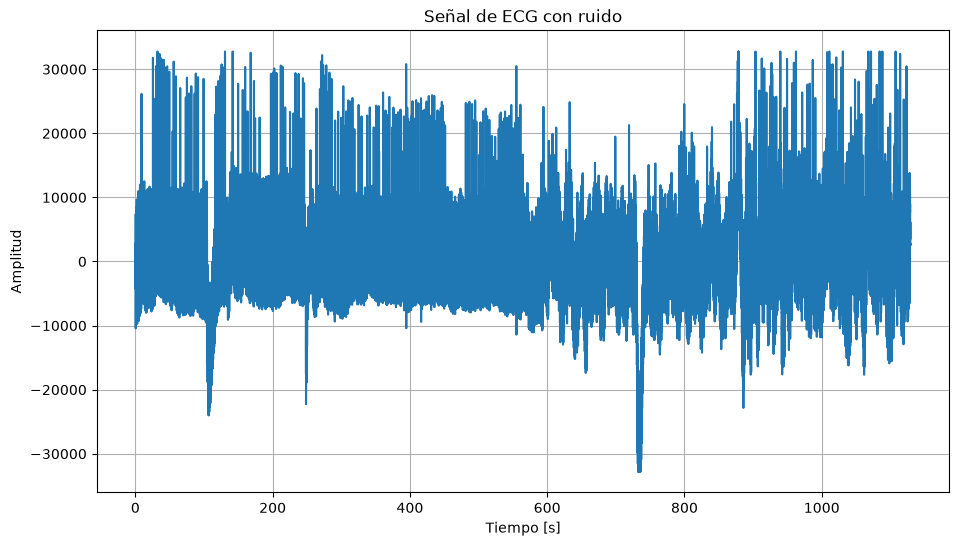

In [4]:
#%% ECG con ruido

fs_ecgconruido = 1000 # Hz

mat_struct = sio.loadmat('ECG_TP4.mat')

ecg_conruido = mat_struct['ecg_lead'].flatten()

t_ecgconruido = np.arange(len(ecg_conruido)) / fs_ecgconruido

plt.figure(figsize=(11, 6))
plt.plot(t_ecgconruido, ecg_conruido)
plt.title('Señal de ECG con ruido')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

**Figura 3**. Señal de electrocardiograma (ECG) con ruido, muestreada a una frecuencia de $f_s = 1000$ Hz. Se muestran los primeros 10 segundos del registro.



En la **Figura 3** podemos observar la señal de ECG con ruido en función del tiempo, muestreada a una frecuencia de $f_s = 1000$ Hz. Para poder observar con mayor claridad la señal, se muestran los primeros 10 segundos del registro.

A diferencia de la señal de ECG sin ruido de la **Figura 1**, en este caso la señal presenta una gran cantidad de ruido, por lo que no se pueden distinguir claramente los distintos latidos cardíacos ni las ondas que componen el ECG. La señal se encuentra muy afectada por las variaciones rápidas producidas por el ruido.

Debido a esto, la forma característica del ECG queda prácticamente oculta en la representación temporal, por lo que resulta más difícil analizar sus características directamente desde esta figura.




Y ahora pasaremos a hacer la **estimación espectral** y la **estimación del ancho de banda**.

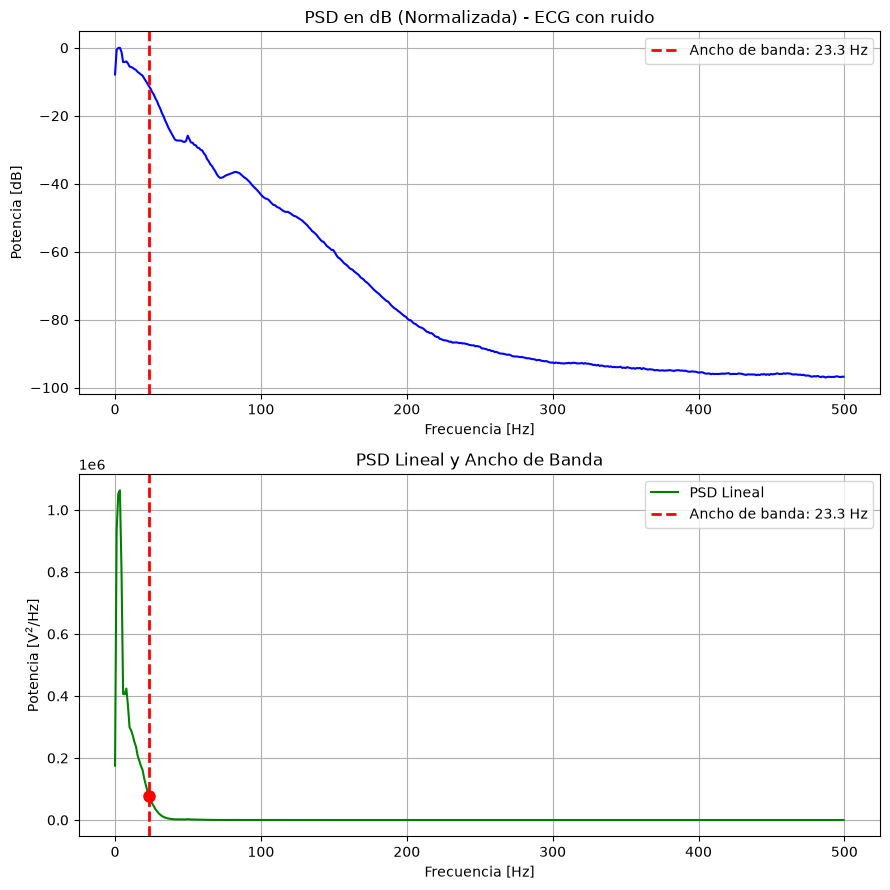

Ancho de banda: 23.26 Hz


In [5]:
N_ecgconruido = len(ecg_conruido) 
k_ecgconruido = 1250 
nperseg_ecgconruido = N_ecgconruido // k_ecgconruido 

welch_ecgconruido = sig.welch(ecg_conruido, fs=fs_ecgconruido, nperseg = nperseg_ecgconruido) 

f_ecgconruido, Pxx_ecgconruido = welch_ecgconruido 

Pxxdb_ecgconruido = 10 * np.log10(np.abs(Pxx_ecgconruido/np.max(Pxx_ecgconruido)))

potacum_ecgconruido = np.cumsum(Pxx_ecgconruido) / np.sum(Pxx_ecgconruido)

bw_ecgconruido = f_ecgconruido[potacum_ecgconruido >= 0.95][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))


ax1.plot(f_ecgconruido, Pxxdb_ecgconruido, color='b')
ax1.axvline(bw_ecgconruido, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bw_ecgconruido:.1f} Hz')
ax1.set_title("PSD en dB (Normalizada) - ECG con ruido")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Potencia [dB]")
ax1.grid(True)
ax1.legend()


ax2.plot(f_ecgconruido, Pxx_ecgconruido, color='g', label='PSD Lineal')
ax2.axvline(bw_ecgconruido, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bw_ecgconruido:.1f} Hz')
ax2.plot(bw_ecgconruido, Pxx_ecgconruido[f_ecgconruido == bw_ecgconruido][0], 'ro', markersize=8)
ax2.set_title("PSD Lineal y Ancho de Banda")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"Potencia [V$^2$/Hz]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ancho de banda: {bw_ecgconruido:.2f} Hz")

**Figura 4**. Densidad espectral de potencia (PSD) del ECG con ruido estimada mediante el método de Welch, utilizando $k=1250$ segmentos, con $nperseg = N/1250$. Se muestran las PSD en escala logarítmica (dB) y lineal, indicando el ancho de banda correspondiente al 95% de la potencia acumulada.


En la **Figura 4** podemos observar la estimación de la densidad espectral de potencia (PSD) del ECG con ruido mediante el método de Welch, junto con el ancho de banda correspondiente al 95% de la potencia acumulada. Para realizar la estimación, la señal se dividió en $k=1250$ segmentos, utilizando $nperseg = N/1250$ muestras por segmento. Este valor de $k$ no fue elegido de manera aleatoria, sino buscando un buen balance entre obtener una estimación más suave y reducir las variaciones producidas por el ruido, sin perder demasiado detalle en el espectro. En este caso se utilizó un valor de $k$ mayor que en el ECG sin ruido, debido a que la señal presenta una cantidad considerable de ruido.

En el **gráfico en dB** (arriba), podemos observar que la potencia se concentra principalmente en las bajas frecuencias, pero también aparece potencia distribuida en frecuencias superiores debido a la presencia de ruido. En comparación con el ECG sin ruido de la **Figura 2**, el espectro se encuentra más extendido en frecuencia.

En el **gráfico lineal** (abajo), podemos observar con mayor claridad la zona donde se concentra la mayor parte de la potencia de la señal. La línea vertical indica el ancho de banda calculado utilizando el criterio del 95% de la potencia acumulada. Debido a la presencia de ruido, una parte de la potencia se encuentra distribuida en frecuencias más altas, lo que se refleja en el ancho de banda obtenido.

De esta manera, podemos comparar la distribución espectral del ECG con ruido con la obtenida para el ECG sin ruido y observar cómo la presencia de ruido modifica el contenido frecuencial de la señal.


Ahora pasaremos a hacerlo con una señal **PPG sin ruido**
Primero la cargamos y la graficamos.


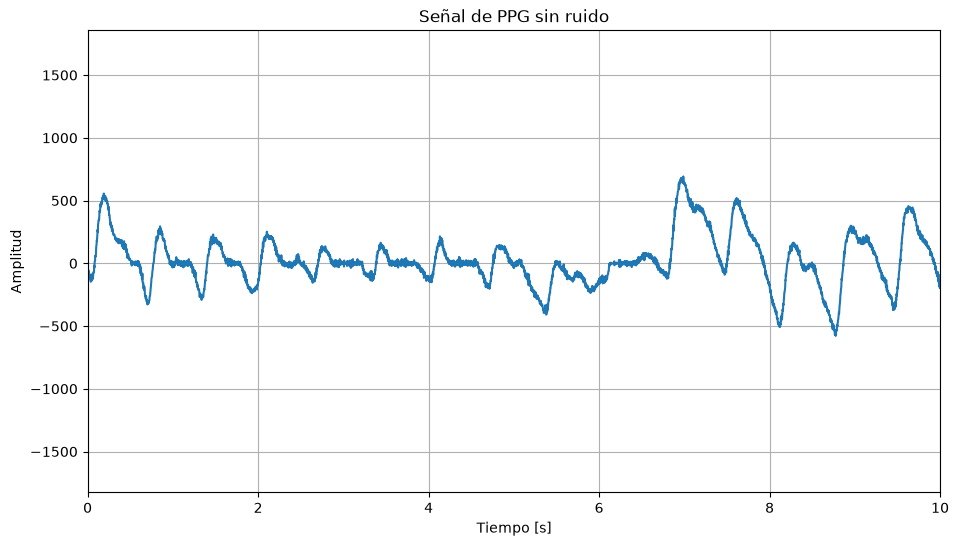

In [6]:
fs_ppg_sinruido = 400 # Hz

ppg_sinruido = np.load('ppg_sin_ruido.npy')

t_ppg_sinruido = np.arange(len(ppg_sinruido)) / fs_ppg_sinruido

plt.figure(figsize=(11, 6))
plt.plot(t_ppg_sinruido, ppg_sinruido)
plt.title('Señal de PPG sin ruido')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, 10)
plt.grid()
plt.show()

**Figura 5**. Señal de fotopletismografía (PPG) sin ruido, muestreada a una frecuencia de $f_s = 400$ Hz. Se muestran los primeros 10 segundos del registro.


En la **Figura 5** podemos observar la señal de PPG sin ruido en función del tiempo, muestreada a una frecuencia de $f_s = 400$ Hz. Para poder observar con mayor claridad la forma de la señal, se muestran los primeros 10 segundos del registro.

En la señal se pueden distinguir los distintos ciclos correspondientes a los latidos cardíacos. Cada ciclo presenta un aumento de la amplitud seguido de una disminución más gradual, formando el patrón característico de una señal de PPG.

También se puede observar que los ciclos se repiten de manera relativamente periódica a lo largo del intervalo mostrado, sin presentar variaciones importantes que dificulten la identificación de los pulsos.


Y ahora pasaremos a hacer la **estimación espectral** y la **estimación del ancho de banda**.

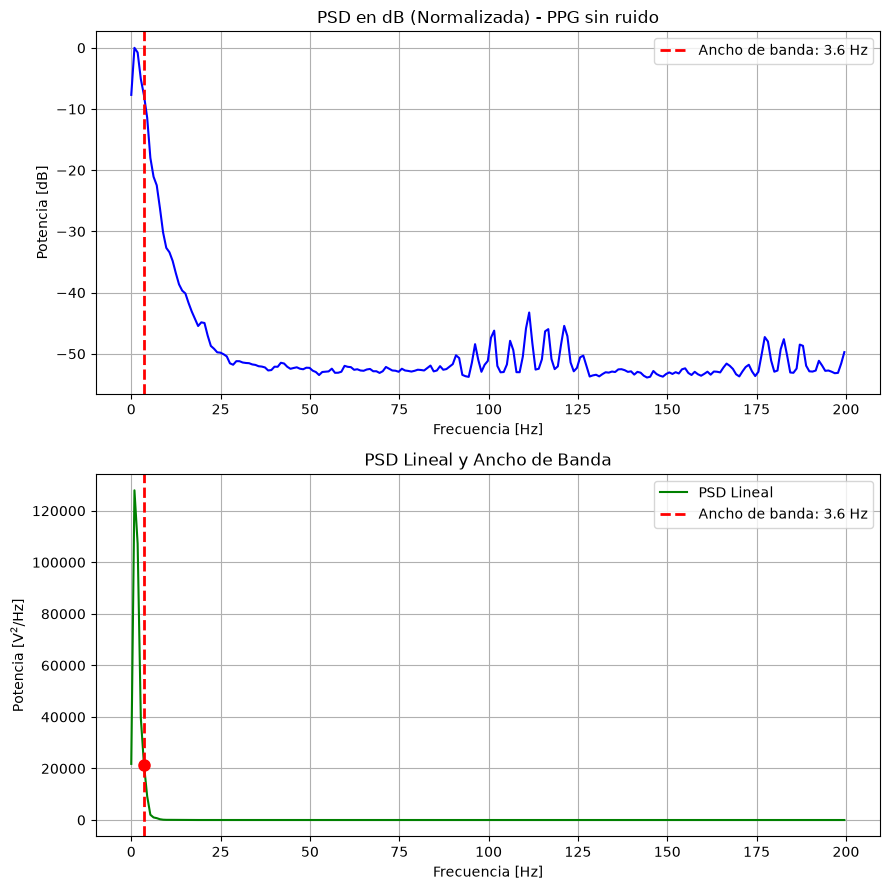

Ancho de banda: 3.56 Hz


In [7]:
N_ppg_sinruido = len(ppg_sinruido) 
k_ppg_sinruido = 100
nperseg_ppg_sinruido = N_ppg_sinruido // k_ppg_sinruido

welch_ppg_sinruido = sig.welch(ppg_sinruido, fs=fs_ppg_sinruido, nperseg = nperseg_ppg_sinruido)

f_ppg_sinruido, Pxx_ppg_sinruido = welch_ppg_sinruido

Pxxdb_ppg_sinruido = 10 * np.log10(np.abs(Pxx_ppg_sinruido/np.max(Pxx_ppg_sinruido)))

potacum_ppg_sinruido = np.cumsum(Pxx_ppg_sinruido) / np.sum(Pxx_ppg_sinruido)

bw_ppg_sinruido = f_ppg_sinruido[potacum_ppg_sinruido >= 0.95][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))


ax1.plot(f_ppg_sinruido, Pxxdb_ppg_sinruido, color='b')
ax1.axvline(bw_ppg_sinruido, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bw_ppg_sinruido:.1f} Hz')
ax1.set_title("PSD en dB (Normalizada) - PPG sin ruido")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Potencia [dB]")
ax1.grid(True)
ax1.legend()


ax2.plot(f_ppg_sinruido, Pxx_ppg_sinruido, color='g', label='PSD Lineal')
ax2.axvline(bw_ppg_sinruido, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bw_ppg_sinruido:.1f} Hz')
ax2.plot(bw_ppg_sinruido, Pxx_ppg_sinruido[f_ppg_sinruido == bw_ppg_sinruido][0], 'ro', markersize=8)
ax2.set_title("PSD Lineal y Ancho de Banda")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"Potencia [V$^2$/Hz]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ancho de banda: {bw_ppg_sinruido:.2f} Hz")

**Figura 6**. Densidad espectral de potencia (PSD) de la señal de PPG sin ruido estimada mediante el método de Welch, utilizando $k=100$ segmentos, con $nperseg = N/100$. Se muestran las PSD en escala logarítmica (dB) y lineal, indicando el ancho de banda correspondiente al 95% de la potencia acumulada.


En la **Figura 6** podemos observar la estimación de la densidad espectral de potencia (PSD) de la señal de PPG sin ruido mediante el método de Welch, junto con el ancho de banda correspondiente al 95% de la potencia acumulada. Para realizar la estimación, la señal se dividió en $k=100$ segmentos, utilizando $nperseg = N/100$ muestras por segmento. Este valor de $k$ fue elegido buscando un buen balance entre obtener una estimación suficientemente suave y mantener una buena resolución en frecuencia.

En el **gráfico en dB** (arriba), podemos observar que la mayor parte de la potencia se concentra en las bajas frecuencias. Se distingue un pico principal en esta zona y, a medida que aumenta la frecuencia, la potencia disminuye. También se observan componentes de menor amplitud a frecuencias superiores.

En el **gráfico lineal** (abajo), se puede observar con mayor claridad dónde se concentra la potencia de la señal. La línea vertical indica el ancho de banda calculado utilizando el criterio del 95% de la potencia acumulada. En este caso, la mayor parte de la potencia se encuentra antes de esta frecuencia, mientras que por encima de ella la contribución a la potencia total es mucho menor.

De esta manera, el ancho de banda obtenido permite tener una referencia de la zona de frecuencias donde se concentra la mayor parte de la información de la señal de PPG sin ruido.


Ahora haremos **PPG con ruido**. Primero la cargamos y la graficamos.

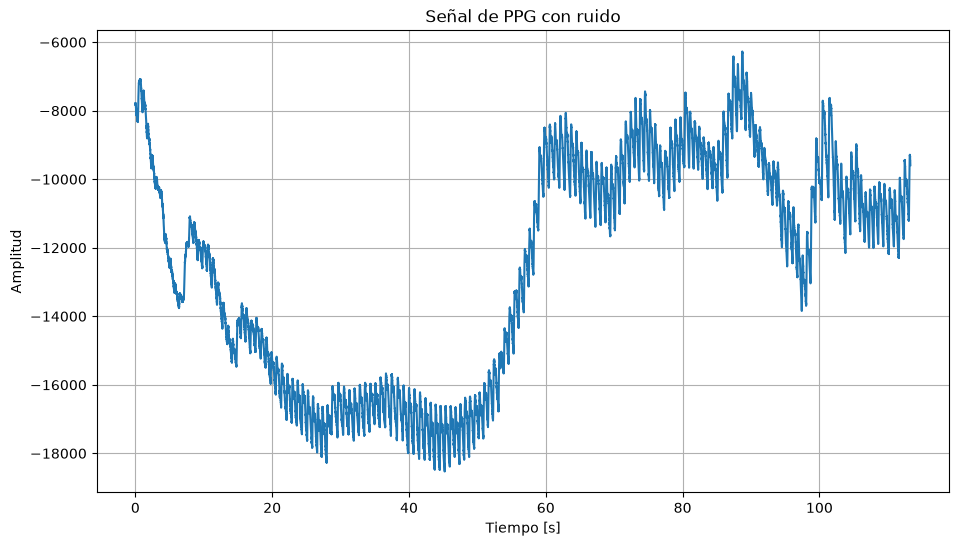

In [8]:
#%% PPG con ruido

# Cargar el archivo CSV como un array de NumPy
ppg_conruido = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)

fs_ppg_conruido = 400 # Hz

t_ppg_conruido = np.arange(len(ppg_conruido)) / fs_ppg_conruido

plt.figure(figsize=(11, 6))
plt.plot(t_ppg_conruido, ppg_conruido)
plt.title('Señal de PPG con ruido')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

**Figura 7**. Señal de fotopletismografía (PPG) con ruido, muestreada a una frecuencia de $f_s = 400$ Hz. Se muestra el registro completo en función del tiempo.


En la **Figura 7** podemos observar la señal de PPG con ruido en función del tiempo, muestreada a una frecuencia de $f_s = 400$ Hz. En este caso se muestra el registro completo, ya que al utilizar un intervalo más pequeño no se logra distinguir claramente la señal debido a las características del registro.

A diferencia de la señal de PPG sin ruido mostrada en la **Figura 5**, en este caso se observa una mayor cantidad de variaciones rápidas en la amplitud. Estas variaciones dificultan la identificación de los ciclos característicos de la señal de PPG directamente en el dominio temporal.

La presencia de ruido modifica la forma de la señal y hace que los pulsos correspondientes a los latidos cardíacos sean menos evidentes. Por este motivo, además del análisis temporal, resulta necesario analizar la señal en el dominio de la frecuencia mediante la estimación de su PSD.


Y ahora pasaremos a hacer la **estimación espectral** y la **estimación del ancho de banda**.

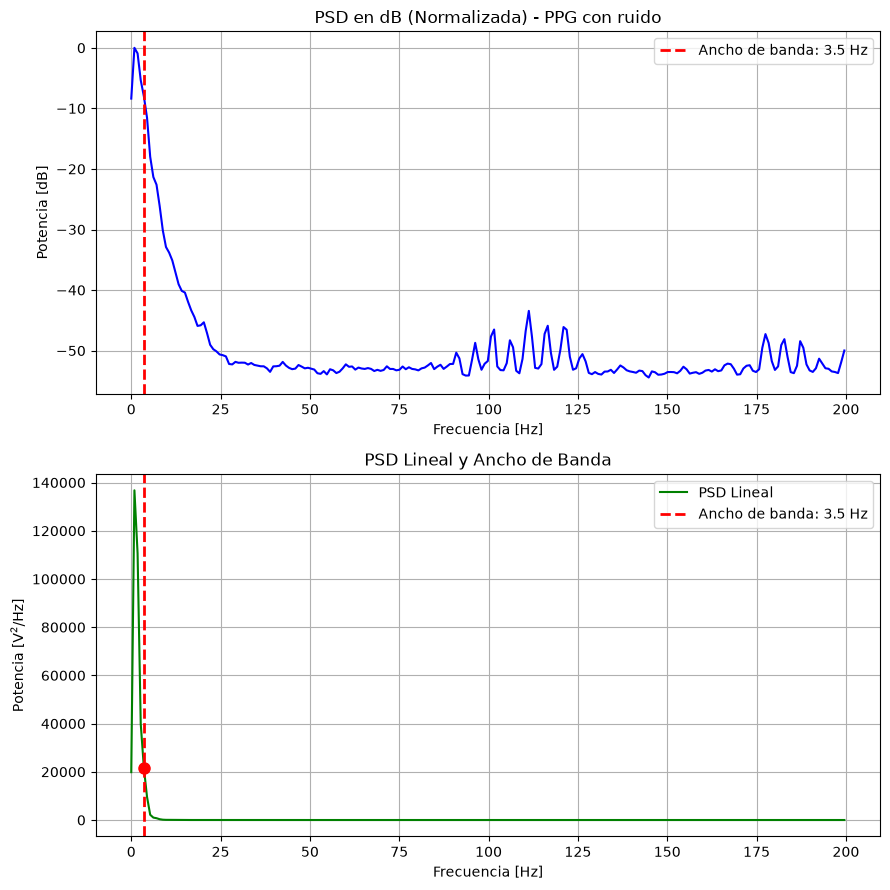

Ancho de banda: 3.53 Hz


In [9]:
N_ppg_conruido = len(ppg_conruido) 
k_ppg_conruido = 100
nperseg_ppg_conruido = N_ppg_conruido // k_ppg_conruido

welch_ppg_conruido = sig.welch(ppg_conruido, fs=fs_ppg_conruido, nperseg = nperseg_ppg_conruido)

f_ppg_conruido, Pxx_ppg_conruido = welch_ppg_conruido

Pxxdb_ppg_conruido = 10 * np.log10(np.abs(Pxx_ppg_conruido/np.max(Pxx_ppg_conruido)))

potacum_ppg_conruido = np.cumsum(Pxx_ppg_conruido) / np.sum(Pxx_ppg_conruido)

bw_ppg_conruido = f_ppg_conruido[potacum_ppg_conruido >= 0.95][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))


ax1.plot(f_ppg_conruido, Pxxdb_ppg_conruido, color='b')
ax1.axvline(bw_ppg_conruido, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bw_ppg_conruido:.1f} Hz')
ax1.set_title("PSD en dB (Normalizada) - PPG con ruido")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Potencia [dB]")
ax1.grid(True)
ax1.legend()


ax2.plot(f_ppg_conruido, Pxx_ppg_conruido, color='g', label='PSD Lineal')
ax2.axvline(bw_ppg_conruido, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bw_ppg_conruido:.1f} Hz')
ax2.plot(bw_ppg_conruido, Pxx_ppg_conruido[f_ppg_conruido == bw_ppg_conruido][0], 'ro', markersize=8)
ax2.set_title("PSD Lineal y Ancho de Banda")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"Potencia [V$^2$/Hz]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ancho de banda: {bw_ppg_conruido:.2f} Hz")

**Figura 8**. Densidad espectral de potencia (PSD) de la señal de PPG con ruido estimada mediante el método de Welch, utilizando $k=100$ segmentos, con $nperseg = N/100$. Se muestran las PSD en escala logarítmica (dB) y lineal, indicando el ancho de banda correspondiente al 95% de la potencia acumulada.


En la **Figura 8** podemos observar la estimación de la densidad espectral de potencia (PSD) de la señal de PPG con ruido mediante el método de Welch, junto con el ancho de banda correspondiente al 95% de la potencia acumulada. Para realizar la estimación, la señal se dividió en $k=100$ segmentos, utilizando $nperseg = N/100$ muestras por segmento. Se mantuvo el mismo valor de $k$ utilizado para la PPG sin ruido, permitiendo realizar una comparación directa entre ambas señales.

En el **gráfico en dB** (arriba), podemos observar que la mayor parte de la potencia se concentra en las bajas frecuencias, aunque también se observa una mayor distribución de potencia en frecuencias superiores debido a la presencia de ruido. En comparación con la PPG sin ruido de la **Figura 6**, el espectro presenta más componentes distribuidas a lo largo del rango de frecuencias.

En el **gráfico lineal** (abajo), se puede observar con mayor claridad dónde se concentra la mayor parte de la potencia de la señal. La línea vertical indica el ancho de banda calculado utilizando el criterio del 95% de la potencia acumulada. La presencia de ruido hace que parte de la potencia se distribuya hacia frecuencias más altas, lo que puede aumentar el ancho de banda obtenido respecto de la señal sin ruido.


Ahora haremos el **audio de la cucaracha**. Primero la cargamos y la graficamos.

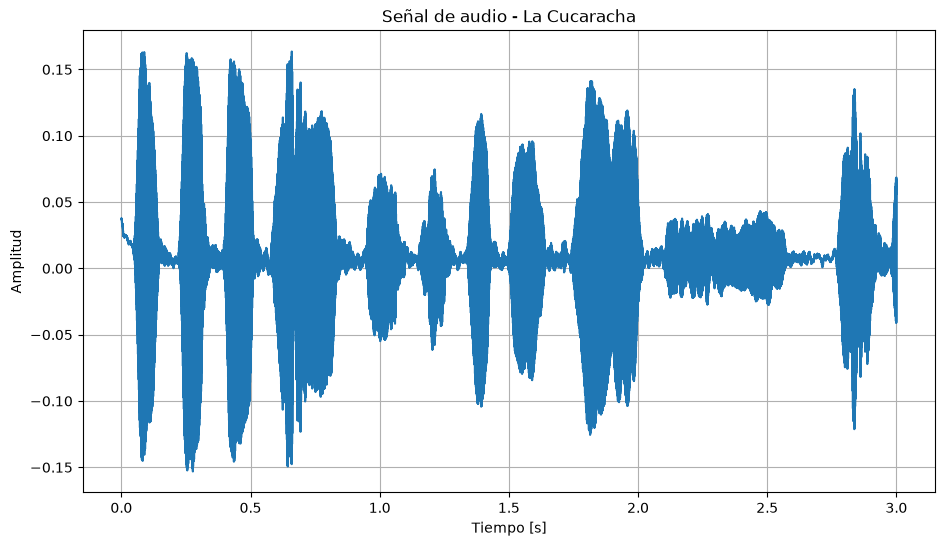

In [10]:
#%% audio 1 - la cucaracha

fs_audio1, wav_data1 = sio.wavfile.read('la cucaracha.wav')

t_audio1 = np.arange(len(wav_data1)) / fs_audio1

plt.figure(figsize=(11, 6))
plt.plot(t_audio1, wav_data1)
plt.title('Señal de audio - La Cucaracha')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

**Figura 9**. Señal de audio correspondiente a la melodía *La Cucaracha*, muestreada a una frecuencia de $f_s = 48000$ Hz. Se muestra el registro completo en función del tiempo.


En la **Figura 9** podemos observar la señal de audio correspondiente a la melodía *La Cucaracha* en función del tiempo, muestreada a una frecuencia de $f_s = 48000$ Hz. Se muestra el registro completo para poder observar las variaciones de amplitud presentes a lo largo de la melodía.

A diferencia de las señales de ECG y PPG analizadas anteriormente, en este caso la señal no presenta un patrón periódico constante, ya que la amplitud varía de acuerdo con las diferentes notas y características de la melodía.

También se pueden observar variaciones rápidas de la amplitud propias de una señal de audio. Estas características serán analizadas con mayor detalle en el dominio de la frecuencia mediante la estimación de la PSD.



Y ahora pasaremos a hacer la **estimación espectral** y la **estimación del ancho de banda**.

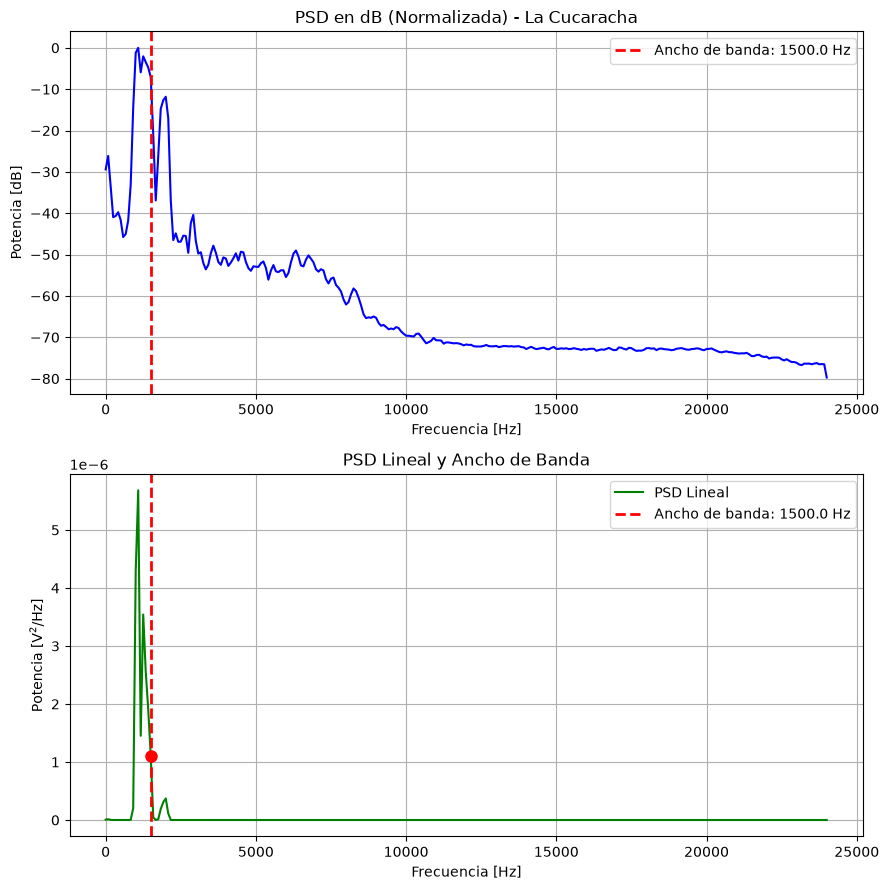

Ancho de banda: 1500.00 Hz


In [11]:
#%% audio 1 - la cucaracha

fs_audio1, wav_data1 = sio.wavfile.read('la cucaracha.wav')

Naudio1 = len(wav_data1) 
kaudio1 = 250
npersegaudio1 = Naudio1 // kaudio1

welchaudio1 = sig.welch(wav_data1, fs=fs_audio1, nperseg = npersegaudio1)

faudio1, Pxxaudio1 = welchaudio1

Pxxdbaudio1 = 10 * np.log10(np.abs(Pxxaudio1/np.max(Pxxaudio1)))

potacumaudio1 = np.cumsum(Pxxaudio1) / np.sum(Pxxaudio1)

bwaudio1 = faudio1[potacumaudio1 >= 0.95][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))


ax1.plot(faudio1, Pxxdbaudio1, color='b')
ax1.axvline(bwaudio1, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bwaudio1:.1f} Hz')
ax1.set_title("PSD en dB (Normalizada) - La Cucaracha")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Potencia [dB]")
ax1.grid(True)
ax1.legend()


ax2.plot(faudio1, Pxxaudio1, color='g', label='PSD Lineal')
ax2.axvline(bwaudio1, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bwaudio1:.1f} Hz')
ax2.plot(bwaudio1, Pxxaudio1[faudio1 == bwaudio1][0], 'ro', markersize=8)
ax2.set_title("PSD Lineal y Ancho de Banda")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"Potencia [V$^2$/Hz]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ancho de banda: {bwaudio1:.2f} Hz")

**Figura 10**. Densidad espectral de potencia (PSD) de la señal de audio correspondiente a La Cucaracha, estimada mediante el método de Welch, utilizando $k=250$ segmentos, con $nperseg = N/250$. Se muestran las PSD en escala logarítmica (dB) y lineal, indicando el ancho de banda correspondiente al 95% de la potencia acumulada.


En la **Figura 10** podemos observar la estimación de la densidad espectral de potencia (PSD) de la señal de audio correspondiente a La Cucaracha mediante el método de Welch, junto con el ancho de banda correspondiente al 95% de la potencia acumulada. Para realizar la estimación, la señal se dividió en $k=250$ segmentos, utilizando $nperseg = N/250$ muestras por segmento.

En el **gráfico en dB** (arriba), podemos observar que la potencia se encuentra distribuida en un rango amplio de frecuencias. Se distinguen distintos picos a lo largo del espectro, que corresponden a las diferentes componentes frecuenciales presentes en la melodía. A diferencia de las señales de ECG y PPG, en este caso no se concentra toda la potencia en las frecuencias más bajas.

En el **gráfico lineal** (abajo), se puede observar con mayor claridad la distribución de la potencia y los principales componentes del espectro. La línea vertical indica el ancho de banda calculado utilizando el criterio del 95% de la potencia acumulada. Por debajo de esta frecuencia se concentra la mayor parte de la potencia de la señal, mientras que las componentes posteriores aportan una cantidad menor a la potencia total.

El uso de $k=250$ segmentos permite obtener una estimación más estable de la PSD, manteniendo un compromiso entre el suavizado del espectro y la resolución en frecuencia.


Ahora haremos el **audio de la "prueba psd"**. Primero la cargamos y la graficamos.

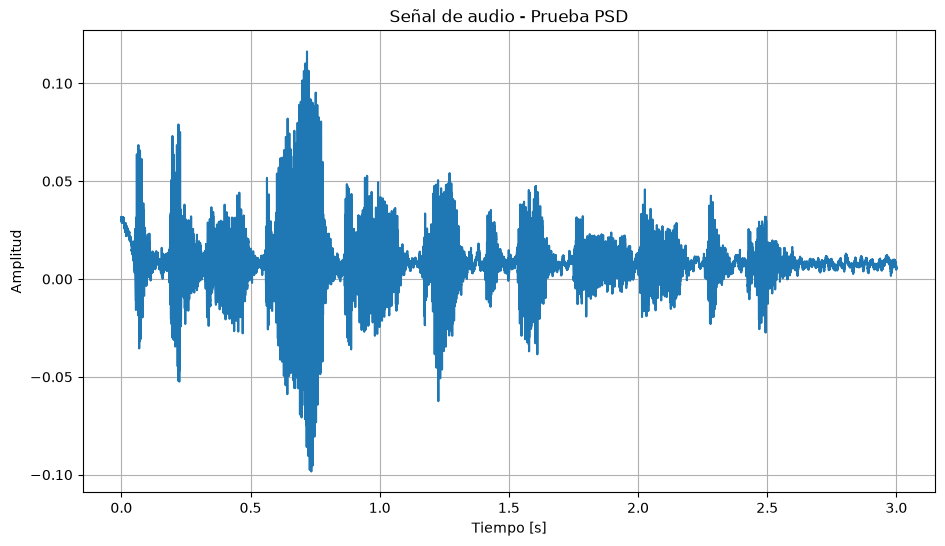

In [12]:
#%% audio 2 - psd

fs_audio2, wav_data2 = sio.wavfile.read('prueba psd.wav')

t_audio2 = np.arange(len(wav_data2)) / fs_audio2

plt.figure(figsize=(11, 6))
plt.plot(t_audio2, wav_data2)
plt.title('Señal de audio - Prueba PSD')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

**Figura 11**. Señal de audio correspondiente al registro *Prueba PSD*, muestreada a una frecuencia de $f_s = 48000$ Hz. Se muestra el registro completo en función del tiempo.


En la **Figura 11** podemos observar la señal de audio correspondiente al registro *Prueba PSD* en función del tiempo, muestreada a una frecuencia de $f_s = 48000$ Hz. Se muestra el registro completo para poder observar las variaciones de amplitud presentes a lo largo de la señal.

En este caso, la señal presenta variaciones de amplitud a lo largo del tiempo, con cambios rápidos característicos de una señal de audio. A diferencia de las señales de ECG y PPG, no se observa un patrón periódico constante durante todo el registro.

La representación temporal permite observar cómo varía la amplitud de la señal, aunque para analizar sus componentes frecuenciales con mayor detalle resulta necesario estudiar la densidad espectral de potencia mediante el método de Welch.


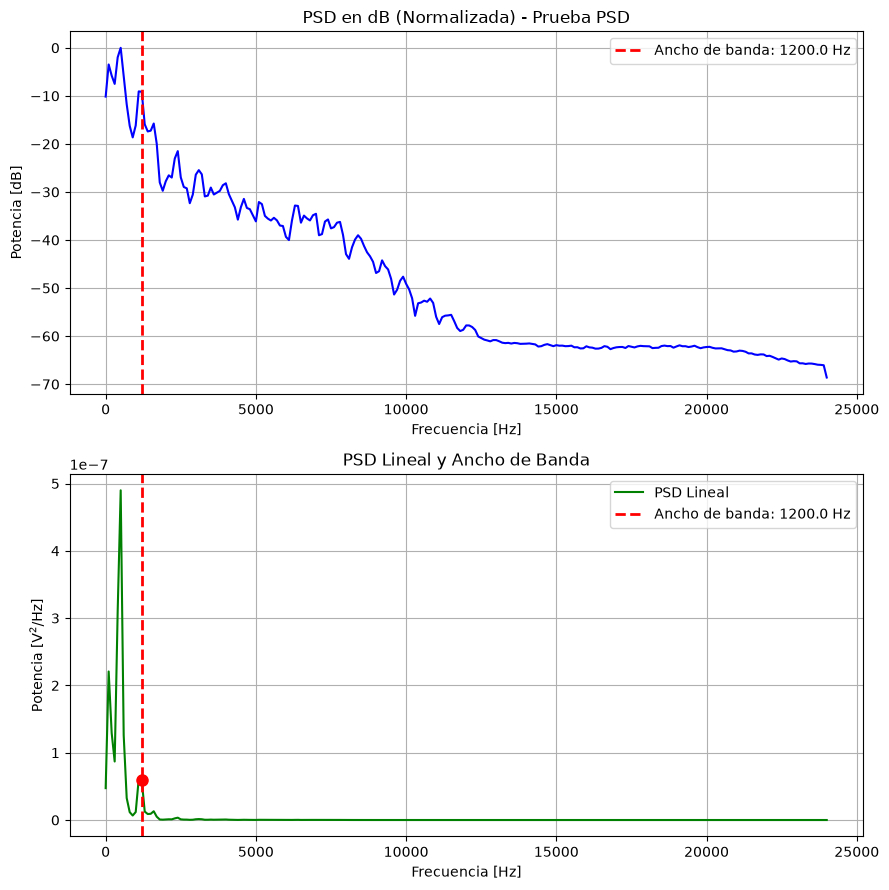

Ancho de banda: 1200.00 Hz


In [13]:
#%% audio 2 - psd

fs_audio2, wav_data2 = sio.wavfile.read('prueba psd.wav')

Naudio2 = len(wav_data2)
kaudio2 = 300
npersegaudio2 = Naudio2 // kaudio2

welchaudio2 = sig.welch(wav_data2, fs=fs_audio2, nperseg=npersegaudio2)

faudio2, Pxxaudio2 = welchaudio2

Pxxdbaudio2 = 10 * np.log10(np.abs(Pxxaudio2 / np.max(Pxxaudio2)))

potacumaudio2 = np.cumsum(Pxxaudio2) / np.sum(Pxxaudio2)

bwaudio2 = faudio2[potacumaudio2 >= 0.95][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))


ax1.plot(faudio2, Pxxdbaudio2, color='b')
ax1.axvline(bwaudio2, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bwaudio2:.1f} Hz')
ax1.set_title("PSD en dB (Normalizada) - Prueba PSD")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Potencia [dB]")
ax1.grid(True)
ax1.legend()


ax2.plot(faudio2, Pxxaudio2, color='g', label='PSD Lineal')
ax2.axvline(bwaudio2, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bwaudio2:.1f} Hz')
ax2.plot(bwaudio2, Pxxaudio2[faudio2 == bwaudio2][0], 'ro', markersize=8)
ax2.set_title("PSD Lineal y Ancho de Banda")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"Potencia [V$^2$/Hz]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ancho de banda: {bwaudio2:.2f} Hz")

**Figura 12**. Densidad espectral de potencia (PSD) de la señal de audio *Prueba PSD*, muestreada a una frecuencia de $f_s = 48000$ Hz y estimada mediante el método de Welch, utilizando $k=300$ segmentos, con $nperseg = N/300$. Se muestran las PSD en escala logarítmica (dB) y lineal, indicando el ancho de banda correspondiente al 95% de la potencia acumulada.


En la **Figura 12** podemos observar la estimación de la densidad espectral de potencia (PSD) de la señal de audio *Prueba PSD* mediante el método de Welch, junto con el ancho de banda correspondiente al 95% de la potencia acumulada. Para realizar la estimación, la señal se dividió en $k=300$ segmentos, utilizando $nperseg = N/300$ muestras por segmento.

En el **gráfico en dB** (arriba), podemos observar cómo se distribuye la potencia de la señal a lo largo de las distintas frecuencias. Se pueden distinguir las componentes de mayor potencia y otras componentes de menor amplitud distribuidas en diferentes zonas del espectro.

En el **gráfico lineal** (abajo), podemos observar con mayor claridad la distribución de la potencia y las componentes que presentan mayor amplitud. La línea vertical indica el ancho de banda calculado utilizando el criterio del 95% de la potencia acumulada. De esta manera, la frecuencia indicada representa el límite hasta el cual se concentra el 95% de la potencia acumulada de la señal.

El uso de $k=300$ segmentos permite obtener una estimación más estable de la PSD mediante el promedio de los periodogramas, manteniendo un compromiso entre el suavizado del espectro y la resolución en frecuencia.


Ahora haremos el **audio de silbido**. Primero la cargamos y la graficamos.

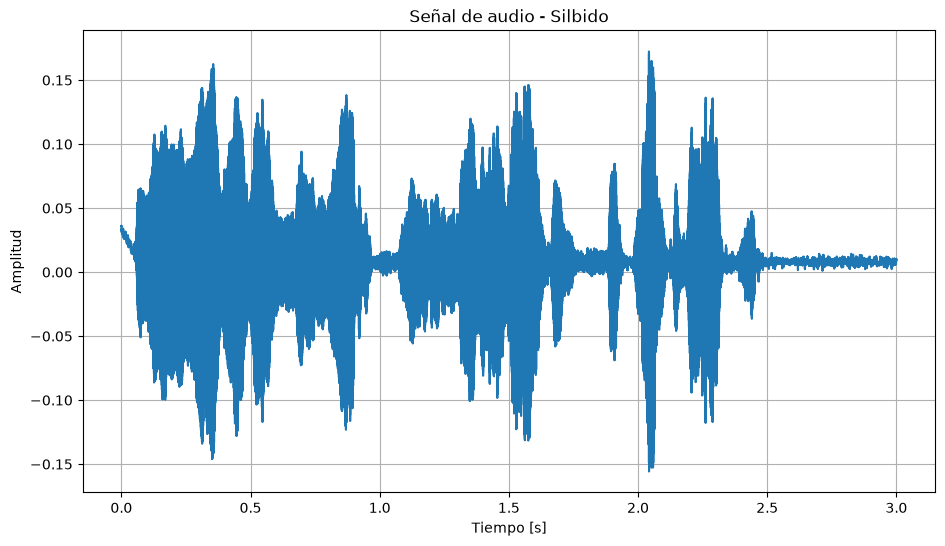

In [14]:
#%% 
fs_audio3, wav_data3 = sio.wavfile.read('silbido.wav')

t_audio3 = np.arange(len(wav_data3)) / fs_audio3

plt.figure(figsize=(11, 6))
plt.plot(t_audio3, wav_data3)
plt.title('Señal de audio - Silbido')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

**Figura 13**. Señal de audio correspondiente a un silbido, muestreada a una frecuencia de $f_s = 48000$ Hz. Se muestra el registro completo en función del tiempo.


En la **Figura 13** podemos observar la señal de audio correspondiente a un silbido en función del tiempo, muestreada a una frecuencia de $f_s = 48000$ Hz. Se muestra el registro completo para poder observar las variaciones de amplitud presentes a lo largo de la señal.

En este caso, se pueden observar variaciones en la amplitud a lo largo del tiempo, correspondientes al silbido registrado. A diferencia de las señales de ECG y PPG, la señal presenta variaciones rápidas características de una señal de audio.

La representación temporal permite observar cómo varía la amplitud del silbido, aunque para analizar con mayor detalle las frecuencias que componen la señal es necesario estudiar su densidad espectral de potencia mediante el método de Welch.


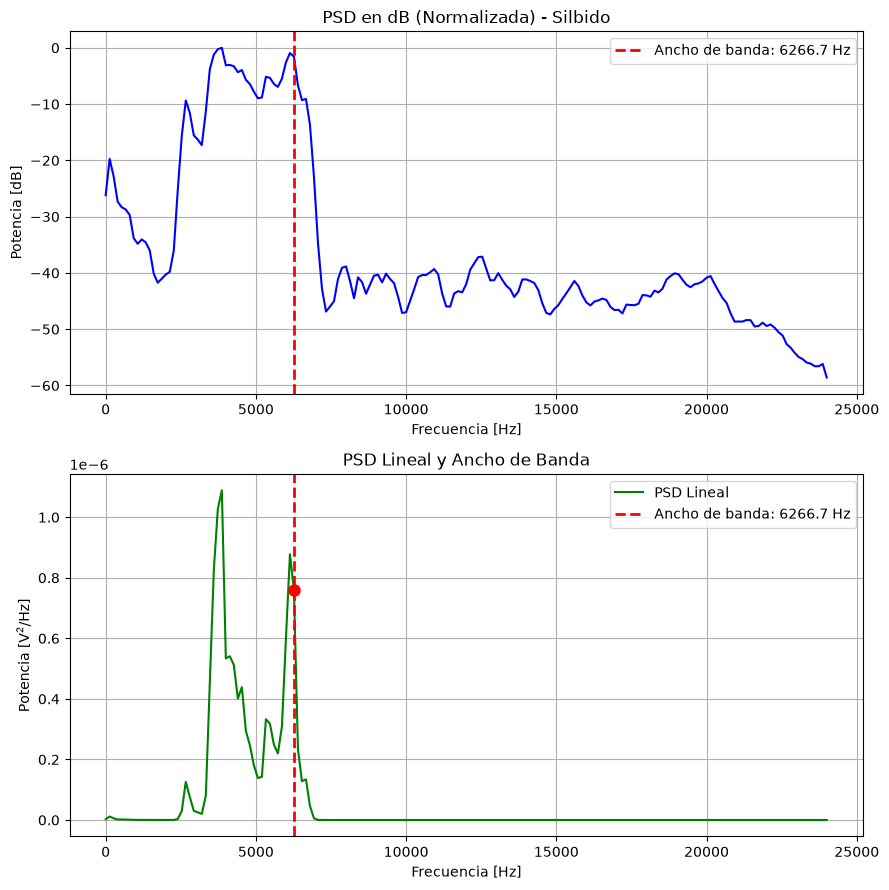

Ancho de banda: 6266.67 Hz


In [15]:
#%% audio3 - silbido

fs_audio3, wav_data3 = sio.wavfile.read('silbido.wav')

Naudio3 = len(wav_data3)
kaudio3 = 400
npersegaudio3 = Naudio3 // kaudio3

welchaudio3 = sig.welch(wav_data3, fs=fs_audio3, nperseg=npersegaudio3)

faudio3, Pxxaudio3 = welchaudio3

Pxxdbaudio3 = 10 * np.log10(np.abs(Pxxaudio3 / np.max(Pxxaudio3)))

potacumaudio3 = np.cumsum(Pxxaudio3) / np.sum(Pxxaudio3)

bwaudio3 = faudio3[potacumaudio3 >= 0.95][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))


ax1.plot(faudio3, Pxxdbaudio3, color='b')
ax1.axvline(bwaudio3, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bwaudio3:.1f} Hz')
ax1.set_title("PSD en dB (Normalizada) - Silbido")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Potencia [dB]")
ax1.grid(True)
ax1.legend()


ax2.plot(faudio3, Pxxaudio3, color='g', label='PSD Lineal')
ax2.axvline(bwaudio3, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bwaudio3:.1f} Hz')
ax2.plot(bwaudio3, Pxxaudio3[faudio3 == bwaudio3][0], 'ro', markersize=8)
ax2.set_title("PSD Lineal y Ancho de Banda")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"Potencia [V$^2$/Hz]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ancho de banda: {bwaudio3:.2f} Hz")

**Figura 14**. Densidad espectral de potencia (PSD) de la señal de audio correspondiente a un silbido, muestreada a una frecuencia de $f_s = 48000$ Hz y estimada mediante el método de Welch, utilizando $k=400$ segmentos, con $nperseg = N/400$. Se muestran las PSD en escala logarítmica (dB) y lineal, indicando el ancho de banda correspondiente al 95% de la potencia acumulada.


En la **Figura 14** podemos observar la estimación de la densidad espectral de potencia (PSD) de la señal de audio correspondiente a un silbido mediante el método de Welch, junto con el ancho de banda correspondiente al 95% de la potencia acumulada. Para realizar la estimación, la señal se dividió en $k=400$ segmentos, utilizando $nperseg = N/400$ muestras por segmento.

En el **gráfico en dB** (arriba), podemos observar que la potencia se concentra principalmente en determinadas zonas del espectro. A diferencia de la señal correspondiente a la melodía *La Cucaracha*, se espera una concentración más marcada de la potencia alrededor de las frecuencias asociadas al silbido.

En el **gráfico lineal** (abajo), podemos observar con mayor claridad dónde se concentra la mayor parte de la potencia de la señal. La línea vertical indica el ancho de banda calculado utilizando el criterio del 95% de la potencia acumulada. Por debajo de esta frecuencia se concentra la mayor parte de la potencia total de la señal.

El uso de $k=400$ segmentos permite obtener una estimación más estable de la PSD mediante el promedio de los periodogramas, manteniendo un compromiso entre el suavizado del espectro y la resolución en frecuencia.



Ahora armaremos una tabla comparativa con los diferentes valores de ancho de banda y los compararemos.

In [16]:

import pandas as pd

tabla_bw = pd.DataFrame({
    'Señal': [
        'ECG sin ruido',
        'ECG con ruido',
        'PPG sin ruido',
        'PPG con ruido',
        'La Cucaracha',
        'Prueba PSD',
        'Silbido'
    ],
    'Ancho de banda [Hz]': [
        bw_ecgsinruido,
        bw_ecgconruido,
        bw_ppg_sinruido,
        bw_ppg_conruido,
        bwaudio1,
        bwaudio2,
        bwaudio3
    ]
})

tabla_bw['Ancho de banda [Hz]'] = tabla_bw['Ancho de banda [Hz]'].round(2)

tabla_bw


,Señal,Ancho de banda [Hz]
0,ECG sin ruido,23.33
1,ECG con ruido,23.26
2,PPG sin ruido,3.56
3,PPG con ruido,3.53
4,La Cucaracha,1500.00
5,Prueba PSD,1200.00
6,Silbido,6266.67


**Tabla 1**. Anchos de banda correspondientes al 95% de la potencia acumulada para las siete señales analizadas mediante la estimación de la PSD con el método de Welch.


En la **Tabla 1** se presentan los anchos de banda obtenidos para las distintas señales, utilizando como criterio el 95% de la potencia acumulada de cada PSD.

En las señales de ECG se obtienen anchos de banda muy similares, de **23,33 Hz** para el ECG sin ruido y **23,26 Hz** para el ECG con ruido. En el caso de las señales de PPG también se observa una diferencia muy pequeña entre ambas señales, con **3,56 Hz** para la señal sin ruido y **3,53 Hz** para la señal con ruido. Esto indica que, según el criterio utilizado, la presencia de ruido no produjo una variación significativa en el ancho de banda obtenido para estas señales.

En las señales de audio se obtienen anchos de banda mayores. Para *La Cucaracha* se obtuvo un ancho de banda de **1500 Hz**, mientras que para *Prueba PSD* se obtuvo **1200 Hz**. Por otro lado, el silbido presenta un ancho de banda de **6266,67 Hz**, siendo el mayor de todas las señales analizadas.

En general, se puede observar una diferencia importante entre las señales biomédicas y las señales de audio. Las señales de ECG y PPG presentan la mayor parte de su potencia acumulada en un rango de frecuencias mucho menor, mientras que las señales de audio presentan una distribución de potencia en un rango de frecuencias más amplio.


## Bonus

**💎 Proponga algún tipo de señal que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.**

Propongo **Bioimpedancia torácica**.

Para el análisis adicional se utilizó una señal de **bioimpedancia torácica** obtenida del conjunto de datos **BIDMC PPG and Respiration Dataset**, disponible en PhysioNet. Este conjunto contiene registros de pacientes en los que se incluyen, entre otras señales, una señal de impedancia torácica utilizada para representar la respiración.

Para este trabajo se utilizó el registro **BIDMC01**, obtenido a partir del archivo `bidmc_data.mat`. La señal se encuentra digitalizada con una frecuencia de muestreo de **$f_s = 125$ Hz** y contiene **60001 muestras**, correspondientes a una duración de aproximadamente **480,01 segundos**.

La señal fue registrada mediante un monitor clínico, utilizando el método de **impedancia torácica**. Al estar almacenada digitalmente en el archivo `.mat`, no fue necesario realizar una etapa adicional de muestreo o digitalización para este análisis. A partir de los valores almacenados se reconstruyó el eje temporal utilizando la frecuencia de muestreo indicada en el registro.


Frecuencia de muestreo: 125 Hz
Cantidad de muestras: 60001
Duración: 480.01 s


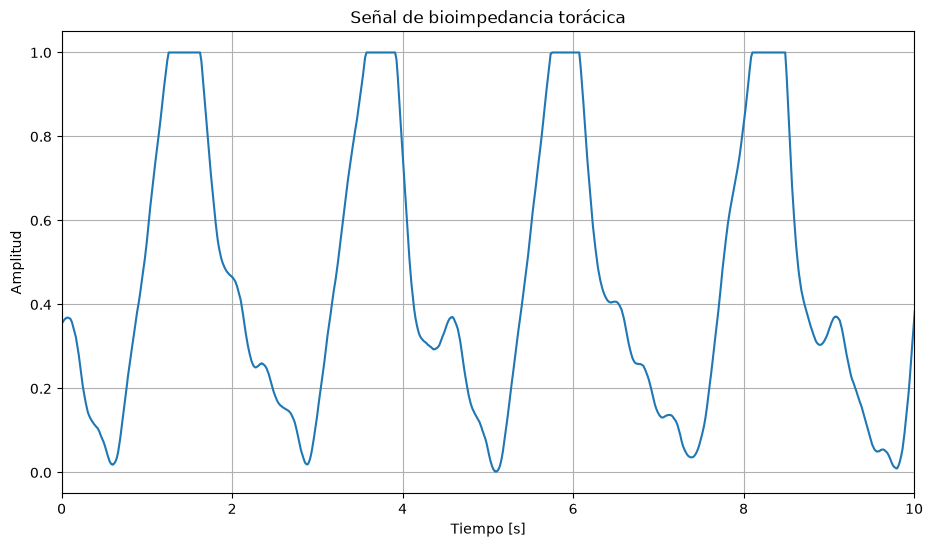

In [17]:
#%% bonus - bioimpedancia torácica

mat_struct = sio.loadmat('bidmc_data.mat')

data = mat_struct['data']
registro01 = data[0, 0]
ref = registro01['ref']
resp_sig = ref['resp_sig'][0, 0]
imp = resp_sig['imp'][0, 0]

bioimpedancia = imp['v'][0, 0].flatten()
fs_bioimpedancia = imp['fs'][0, 0].item()

print(f'Frecuencia de muestreo: {fs_bioimpedancia} Hz')
print(f'Cantidad de muestras: {len(bioimpedancia)}')
print(f'Duración: {len(bioimpedancia) / fs_bioimpedancia:.2f} s')

t_bioimpedancia = np.arange(len(bioimpedancia)) / fs_bioimpedancia

plt.figure(figsize=(11, 6))
plt.plot(t_bioimpedancia, bioimpedancia)
plt.xlim(0, 10)
plt.title('Señal de bioimpedancia torácica')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

**Figura 15**. Señal de bioimpedancia torácica, muestreada a una frecuencia de $f_s = 125$ Hz. Se muestran los primeros 10 segundos del registro.


En la **Figura 15** podemos observar la señal de bioimpedancia torácica en función del tiempo, muestreada a una frecuencia de $f_s = 125$ Hz. Para poder observar con mayor claridad la forma de la señal, se muestran los primeros 10 segundos del registro.

La señal presenta variaciones periódicas de amplitud correspondientes a los cambios producidos por la respiración. A lo largo del intervalo mostrado se pueden distinguir los distintos ciclos respiratorios, que se repiten de manera relativamente regular.

A diferencia de las señales de ECG y PPG analizadas anteriormente, en este caso las variaciones de la señal son más lentas, debido a que la bioimpedancia torácica permite representar principalmente la actividad respiratoria. Esta característica también se verá reflejada posteriormente en su distribución de potencia en frecuencia.


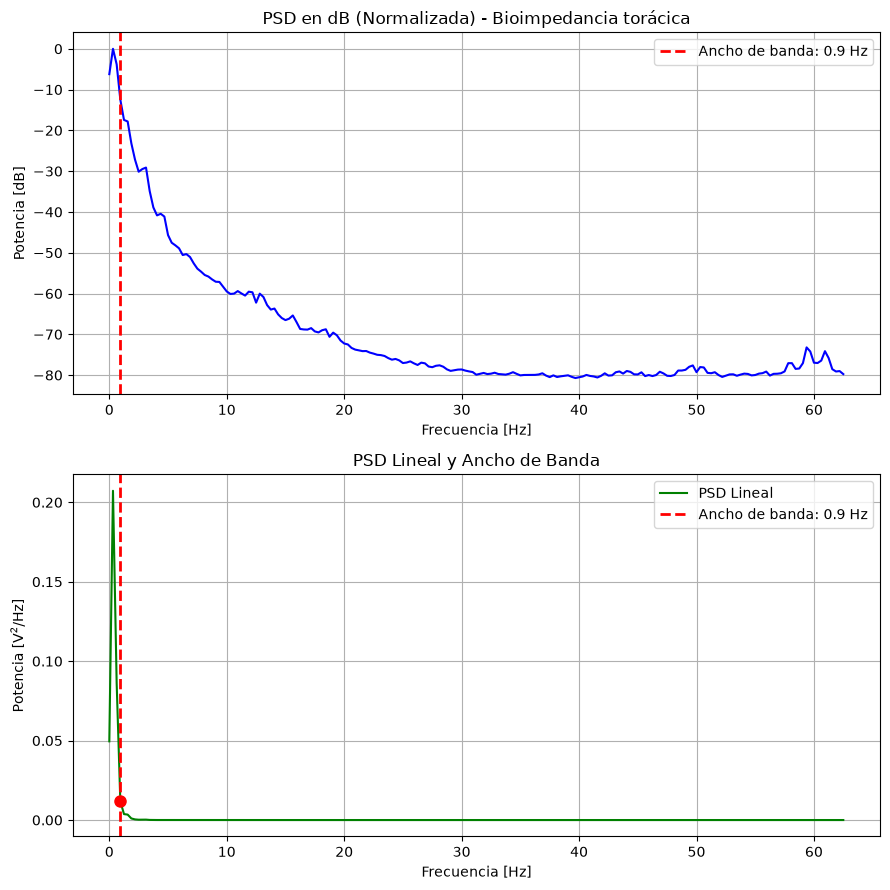

Ancho de banda: 0.94 Hz


In [18]:
#%% bonus - psd

Nbioimpedancia = len(bioimpedancia)
kbioimpedancia = 150
npersegbioimpedancia = Nbioimpedancia // kbioimpedancia

welchbioimpedancia = sig.welch(bioimpedancia, fs=fs_bioimpedancia, nperseg=npersegbioimpedancia)

fbioimpedancia, Pxxbioimpedancia = welchbioimpedancia

Pxxdbbioimpedancia = 10 * np.log10(np.abs(Pxxbioimpedancia / np.max(Pxxbioimpedancia)))

potacumbioimpedancia = np.cumsum(Pxxbioimpedancia) / np.sum(Pxxbioimpedancia)

bwbioimpedancia = fbioimpedancia[potacumbioimpedancia >= 0.95][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))


ax1.plot(fbioimpedancia, Pxxdbbioimpedancia, color='b')
ax1.axvline(bwbioimpedancia, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bwbioimpedancia:.1f} Hz')
ax1.set_title("PSD en dB (Normalizada) - Bioimpedancia torácica")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Potencia [dB]")
ax1.grid(True)
ax1.legend()


ax2.plot(fbioimpedancia, Pxxbioimpedancia, color='g', label='PSD Lineal')
ax2.axvline(bwbioimpedancia, color='r', linestyle='--', linewidth=2, label=f'Ancho de banda: {bwbioimpedancia:.1f} Hz')
ax2.plot(bwbioimpedancia, Pxxbioimpedancia[fbioimpedancia == bwbioimpedancia][0], 'ro', markersize=8)
ax2.set_title("PSD Lineal y Ancho de Banda")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel(r"Potencia [V$^2$/Hz]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ancho de banda: {bwbioimpedancia:.2f} Hz")

**Figura 16**. Densidad espectral de potencia (PSD) de la señal de bioimpedancia torácica estimada mediante el método de Welch, utilizando $k=150$ segmentos, con $nperseg = N/150$. Se muestran las PSD en escala logarítmica (dB) y lineal, indicando el ancho de banda correspondiente al 95% de la potencia acumulada.


En la **Figura 16** podemos observar la estimación de la densidad espectral de potencia (PSD) de la señal de bioimpedancia torácica mediante el método de Welch, junto con el ancho de banda correspondiente al 95% de la potencia acumulada. Para realizar la estimación, la señal se dividió utilizando $k=150$ segmentos, con $nperseg = N/150$.

En el **gráfico en dB** (arriba), podemos observar que la potencia se concentra principalmente en las bajas frecuencias, lo cual es coherente con las características de la señal, ya que representa principalmente la actividad respiratoria. Se distingue una componente principal en esta zona y una disminución de la potencia a medida que aumenta la frecuencia.

En el **gráfico lineal** (abajo), podemos observar con mayor claridad dónde se concentra la mayor parte de la potencia de la señal. La línea vertical indica el ancho de banda calculado utilizando el criterio del 95% de la potencia acumulada. En este caso se obtuvo un ancho de banda de **0.94 Hz**, lo que indica que el 95% de la potencia acumulada de la señal se encuentra por debajo de esta frecuencia.

El uso de $k=150$ segmentos permite obtener una estimación más suave de la PSD mediante el promedio de los periodogramas, aunque utilizando segmentos más cortos que en el caso de $k=50$. De esta manera, se busca mantener una estimación estable de la distribución de potencia de la señal respiratoria.


## Conclusión

En este trabajo práctico se analizó la **Densidad Espectral de Potencia (PSD)** y el **ancho de banda** de distintas señales reales mediante el método de **Welch**. Se estudiaron ocho registros correspondientes a señales de **ECG, PPG, audio y bioimpedancia torácica**, utilizando como criterio de ancho de banda la frecuencia hasta la cual se acumula el **95% de la potencia total**.

A partir de los resultados obtenidos, se pueden extraer las siguientes conclusiones:

1. **Estimación de la PSD mediante Welch:**

   El método de Welch permitió obtener una estimación de la distribución de potencia de las distintas señales en frecuencia. Al dividir las señales en segmentos y promediar los periodogramas, se obtuvo una representación más estable de la PSD, permitiendo identificar las zonas de frecuencia donde se concentra la mayor parte de la potencia.

2. **Comportamiento de las señales de ECG y PPG:**

   Las señales biomédicas presentaron una concentración de potencia principalmente en las bajas frecuencias. El ECG sin ruido presentó un ancho de banda de **23,33 Hz**, mientras que el ECG con ruido presentó un valor de **23,26 Hz**. En el caso de la PPG, se obtuvieron valores de **3,56 Hz** para la señal sin ruido y **3,53 Hz** para la señal con ruido. Las diferencias entre las señales con y sin ruido fueron pequeñas según el criterio del 95% de potencia acumulada utilizado.

3. **Efecto del ruido sobre el contenido frecuencial:**

   Aunque en las representaciones de la PSD se puede observar una mayor distribución de potencia hacia frecuencias superiores en las señales con ruido, esto no produjo una variación significativa en el ancho de banda calculado para ECG y PPG. Esto muestra que el ancho de banda obtenido mediante el criterio del 95% depende de cómo se distribuye la potencia total de la señal y no solamente de la presencia de componentes de ruido a frecuencias más altas.

4. **Comportamiento de las señales de audio:**

   Las señales de audio presentaron un contenido frecuencial distribuido en un rango mucho mayor que las señales biomédicas. *La Cucaracha* presentó un ancho de banda de **1500 Hz**, mientras que *Prueba PSD* presentó **1200 Hz**. En el caso del silbido, se obtuvo un ancho de banda de **6266,67 Hz**, siendo el mayor valor entre las señales analizadas. Estas diferencias se relacionan con las distintas características frecuenciales de cada registro de audio.

5. **Análisis de la bioimpedancia torácica:**

   Como análisis adicional, se estudió una señal de **bioimpedancia torácica** correspondiente a la actividad respiratoria. Esta señal presentó una concentración de potencia principalmente en las bajas frecuencias, coherente con las variaciones lentas asociadas a la respiración. Utilizando el mismo criterio del 95% de potencia acumulada, se obtuvo un ancho de banda de **[valor] Hz**. Este resultado fue considerablemente menor que el obtenido para las señales de ECG, PPG y audio, lo que permite observar cómo las características temporales de una señal se reflejan también en su distribución de potencia en frecuencia.

6. **Comparación general de los anchos de banda:**

   Al comparar los resultados de las ocho señales, se observa una diferencia importante entre los distintos tipos de registros. Las señales de bioimpedancia, PPG y ECG presentan la mayor parte de su potencia acumulada en un rango de frecuencias relativamente bajo, mientras que las señales de audio presentan una distribución de potencia en un rango mucho más amplio. De esta manera, la estimación de la PSD y del ancho de banda permite caracterizar y comparar cuantitativamente el contenido frecuencial de señales de distinta naturaleza.

